# Summarize Saved Metrics Across Explainers

This notebook reads exported CSVs under `resources/results/summary_ready/` and summarizes metrics/curves across explainers without recomputing explanations.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _bootstrap_layout(start: Path | None = None) -> tuple[Path, Path]:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "I_explainer_benchmark" / "notebooks").is_dir():
            return candidate, candidate / "I_explainer_benchmark"
        if candidate.name == "I_explainer_benchmark" and (candidate / "notebooks").is_dir():
            return candidate, candidate
    raise RuntimeError(f"Could not locate project/benchmark roots from {here}")


PROJECT_ROOT, BENCHMARK_ROOT = _bootstrap_layout()
REPO_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

summary_roots = [
    PROJECT_ROOT / "resources" / "results" / "summary_ready",
    BENCHMARK_ROOT / "resources" / "results" / "summary_ready",
]
SUMMARY_ROOTS = [p for p in dict.fromkeys(summary_roots) if p.exists()]
if not SUMMARY_ROOTS:
    SUMMARY_ROOTS = [summary_roots[0]]
SUMMARY_ROOT = SUMMARY_ROOTS[0]
print("SUMMARY_ROOTS:", [str(p) for p in SUMMARY_ROOTS])

results_roots = [
    BENCHMARK_ROOT / "resources" / "results",
    PROJECT_ROOT / "resources" / "results",
]
RESULTS_ROOT = next((p for p in results_roots if p.exists()), results_roots[0])
SUMMARY_ROOT


SUMMARY_ROOTS: ['/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready']


PosixPath('/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready')

In [2]:
# Configuration
DATASET = "simulate_v1"   # set to None for all datasets
MODEL = "tgn"             # default to the simulate_v1 TGN cohort
EXPLAINERS = None            # e.g. ["cody", "tgnnexplainer"]
EXPLAINERS_EXCLUDE = ["cf_beam_floor_balanced", "cf_beam_floor"]  # drop old/redundant aliases
VARIANTS = None              # e.g. ["official", "zero_at_s0"]
RUN_SELECTION = "latest_per_explainer_variant"
# one of: "latest_per_explainer_variant", "latest_per_explainer", "all"

USE_PINNED_COHORT = False
PINNED_RUN_IDS_BY_COMBO = {
    ("simulate_v1", "tgat"): [
        "simulate_v1_tgat_official_cody_20260313_163029",
        "simulate_v1_tgat_cf_metric_opt_upper_20260313_165653",
        "simulate_v1_tgat_official_random_20260313_162757",
        "simulate_v1_tgat_official_temgx_20260313_162809",
        "simulate_v1_tgat_official_tempme_20260313_170316",
        "simulate_v1_tgat_official_greedy_20260313_162853",
        "simulate_v1_tgat_official_pg_20260313_162843",
        "simulate_v1_tgat_official_khop_20260313_162831",
        "simulate_v1_tgat_official_tgnnexplainer_20260313_164324",
    ],
}

METRICS_TO_PLOT = [
    "best_fid",
    "aufsc",
    "temgx_aufsc",
    "tempme_acc_auc.ratio_acc",
    "cody_AUFSC_plus",
    "cody_AUFSC_minus",
    "cody_CHARR",
    "flip_success_rate",
]

Fidelity_Y = "fid_inv_best"  # "fid_inv" or "fid_inv_best"

# Plot/export styling
PLOT_STYLE = "seaborn-v0_8-whitegrid"
PLOT_DPI = 180
PLOT_BG = "#f8fafc"
PLOT_GRID = "#d8e0ea"
EXPLAINER_BASE_COLORS = {
    "cf_metric_opt_upper": "#2865EB",
    "my_cf": "#2865EB",
    "cody": "#F59F0F",
    "greedy": "#12A6E9",
    "temgx": "#EF4747",
    "tgnnexplainer": "#18B9A7",
    "pg": "#8D5EF5",
    "perturb_one": "#8D5EF5",
    "tempme": "#F97519",
    "khop": "#8D5C2E",
    "khop_closer": "#8D5C2E",
    "random": "#E1204B",
}
EXPLAINER_ORDER_ALIASES = {
    "my_cf": "cf_metric_opt_upper",
    "khop_closer": "khop",
}
EXPLAINER_PREFERRED_ORDER = [
    "cf_metric_opt_upper",
    "cody",
    "greedy",
    "temgx",
    "tgnnexplainer",
    "pg",
    "tempme",
    "khop",
    "random",
]
PLOT_COLORWAY = [
    "#334155",
    "#64748b",
    "#0f172a",
    "#94a3b8",
]

summary_views_dir = SUMMARY_ROOT / "summary_views"
summary_views_dir.mkdir(parents=True, exist_ok=True)
PLOT_PDF_DIR = summary_views_dir / "figures_pdf"
PLOT_PDF_DIR.mkdir(parents=True, exist_ok=True)


def _safe_slug(text: object) -> str:
    out = []
    for ch in str(text):
        if ch.isalnum() or ch in ("-", "_"):
            out.append(ch)
        elif ch in (" ", "/", "|", "."):
            out.append("-")
    slug = "".join(out).strip("-").lower()
    while "--" in slug:
        slug = slug.replace("--", "-")
    return slug or "plot"


def _plot_tag() -> str:
    return (
        f"dataset-{_safe_slug(DATASET or 'all')}"
        f"_model-{_safe_slug(MODEL or 'all')}"
        f"_mode-{_safe_slug(RUN_SELECTION)}"
    )


def _save_pdf(fig: plt.Figure, name: str) -> Path:
    path = PLOT_PDF_DIR / f"{_safe_slug(name)}_{_plot_tag()}.pdf"
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight", facecolor=fig.get_facecolor())
    print("Saved plot pdf:", path)
    return path


def _explainer_key(label: object) -> str:
    name = str(label)
    return str(EXPLAINER_ORDER_ALIASES.get(name, name))


def _ordered_explainers(labels: list[str]) -> list[str]:
    unique = []
    seen = set()
    for x in labels:
        s = str(x)
        if s in seen:
            continue
        seen.add(s)
        unique.append(s)

    priority = {name: idx for idx, name in enumerate(EXPLAINER_PREFERRED_ORDER)}
    default_rank = len(priority)
    return sorted(
        unique,
        key=lambda name: (
            priority.get(_explainer_key(name), default_rank),
            _explainer_key(name),
            str(name),
        ),
    )


def _color_map(labels: list[str]) -> dict[str, str]:
    ordered = _ordered_explainers(labels)
    cmap = {}
    fallback_idx = 0
    for lab in ordered:
        key = _explainer_key(lab)
        if key in EXPLAINER_BASE_COLORS:
            cmap[lab] = EXPLAINER_BASE_COLORS[key]
        else:
            cmap[lab] = PLOT_COLORWAY[fallback_idx % len(PLOT_COLORWAY)]
            fallback_idx += 1
    return cmap


try:
    plt.style.use(PLOT_STYLE)
except Exception:
    pass

plt.rcParams.update(
    {
        "figure.facecolor": PLOT_BG,
        "axes.facecolor": PLOT_BG,
        "savefig.facecolor": PLOT_BG,
        "axes.edgecolor": "#c9d5e3",
        "axes.labelcolor": "#0f172a",
        "axes.titleweight": "semibold",
        "xtick.color": "#334155",
        "ytick.color": "#334155",
        "grid.color": PLOT_GRID,
        "grid.linestyle": "--",
        "grid.alpha": 0.45,
        "legend.frameon": False,
    }
)

DROP_STYLE_METRICS = [
    "cody_AUFSC_plus",
    "cody_CHARR",
    "best_fid",
    "aufsc",
    "tempme_acc_auc.ratio_acc",
    "flip_success_rate",
]

KEEP_STYLE_METRICS = [
    "cody_AUFSC_minus",
    "best_fid_raw",
    "best_fid_raw_sparsity",
    "first_flip_sparsity",
]




In [3]:
def _read_csv(name: str) -> pd.DataFrame:
    frames = []
    for root in SUMMARY_ROOTS:
        path = root / name
        if not path.exists():
            continue
        df = pd.read_csv(path)
        if df.empty:
            continue
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    merged = pd.concat(frames, ignore_index=True)
    return merged.drop_duplicates().reset_index(drop=True)

manifest = _read_csv("manifest.csv")
metrics_long = _read_csv("all_metric_summary_long.csv")
curve_mean = _read_csv("all_fidelity_curve_mean.csv")
curve_long = _read_csv("all_fidelity_curve_long.csv")
cody_style = _read_csv("all_cody_style_summary.csv")

if manifest.empty:
    raise RuntimeError(
        "No saved summary data found across summary roots: "
        f"{[str(p) for p in SUMMARY_ROOTS]}. "
        "Run exporter cells in notebooks 09/14/23/24/27 first."
    )

for _df in (manifest, metrics_long, curve_mean, curve_long, cody_style):
    if not _df.empty and "created_at" in _df.columns:
        _df["created_at"] = pd.to_datetime(_df["created_at"], errors="coerce", utc=True)

print("manifest rows   :", len(manifest))
print("metrics rows    :", len(metrics_long))
print("curve_mean rows :", len(curve_mean))
print("curve_long rows :", len(curve_long))
print("cody_style rows :", len(cody_style))


manifest rows   : 131
metrics rows    : 2583
curve_mean rows : 5481
curve_long rows : 202608
cody_style rows : 131


/var/folders/k7/xf0yhfbs02ggfm7n1l5g_cnm0000gn/T/ipykernel_32119/3431062977.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [4]:
def _apply_filters(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    if DATASET is not None and "dataset" in out.columns:
        out = out[out["dataset"].astype(str) == str(DATASET)]
    if MODEL is not None and "model" in out.columns:
        out = out[out["model"].astype(str) == str(MODEL)]
    if EXPLAINERS is not None and "explainer" in out.columns:
        keep = {str(x) for x in EXPLAINERS}
        out = out[out["explainer"].astype(str).isin(keep)]
    if EXPLAINERS_EXCLUDE is not None and "explainer" in out.columns:
        drop = {str(x) for x in EXPLAINERS_EXCLUDE}
        out = out[~out["explainer"].astype(str).isin(drop)]
    if VARIANTS is not None and "variant" in out.columns:
        keep = {str(x) for x in VARIANTS}
        out = out[out["variant"].astype(str).isin(keep)]
    return out.reset_index(drop=True)

def _pinned_run_ids() -> set[str]:
    if not USE_PINNED_COHORT:
        return set()
    combo = (str(DATASET) if DATASET is not None else None, str(MODEL) if MODEL is not None else None)
    pinned = PINNED_RUN_IDS_BY_COMBO.get(combo)
    if not pinned:
        return set()
    return {str(x) for x in pinned}

def _select_runs(curve_df: pd.DataFrame) -> set[str]:
    if curve_df.empty:
        pinned = _pinned_run_ids()
        return pinned if pinned else set()
    pinned = _pinned_run_ids()
    if pinned:
        available = set(curve_df["run_id"].astype(str).unique().tolist())
        selected = pinned & available
        if selected:
            return selected
    df = curve_df.copy()
    if "created_at" not in df.columns:
        return set(df["run_id"].astype(str).unique().tolist())

    sort_cols = ["created_at", "run_id"]
    df = df.sort_values(sort_cols)

    if RUN_SELECTION == "all":
        return set(df["run_id"].astype(str).unique().tolist())

    if RUN_SELECTION == "latest_per_explainer":
        grp_cols = [c for c in ["explainer"] if c in df.columns]
    else:
        grp_cols = [c for c in ["explainer", "variant"] if c in df.columns]

    if not grp_cols:
        return set(df["run_id"].astype(str).unique().tolist())

    latest = df.groupby(grp_cols, as_index=False).tail(1)
    return set(latest["run_id"].astype(str).unique().tolist())

curve_mean_f = _apply_filters(curve_mean)
selected_run_ids = _select_runs(curve_mean_f)
if not selected_run_ids:
    selected_run_ids = set(_apply_filters(manifest)["run_id"].astype(str).unique().tolist())

manifest_sel = _apply_filters(manifest)
manifest_sel = manifest_sel[manifest_sel["run_id"].astype(str).isin(selected_run_ids)].copy()
manifest_sel = manifest_sel.sort_values([c for c in ["created_at", "run_id"] if c in manifest_sel.columns]).reset_index(drop=True)

print("Selected runs:", len(selected_run_ids))
print("RUN_FILTER_COMBO:", f"{DATASET or 'all'}/{MODEL or 'all'}", "| mode:", RUN_SELECTION)
if _pinned_run_ids():
    print("PINNED_COHORT:", sorted(_pinned_run_ids()))
current_run_cols = [
    c for c in ["explainer_group", "explainer", "variant", "source_notebook", "run_id", "created_at"]
    if c in manifest_sel.columns
]
if manifest_sel.empty:
    raise RuntimeError(
        "No runs found for the selected dataset/model combo. "
        f"Current filter: {DATASET or 'all'}/{MODEL or 'all'} | mode={RUN_SELECTION}. "
        "Run the corresponding exporter notebooks first, e.g. 23/24/27 for greedy/khop/pg."
    )
else:
    print("Current runs for this dataset/model combo:")
    display(manifest_sel[current_run_cols].sort_values([c for c in ["explainer_group", "explainer", "variant", "created_at", "run_id"] if c in current_run_cols]).reset_index(drop=True))


Selected runs: 9
RUN_FILTER_COMBO: simulate_v1/tgn | mode: latest_per_explainer_variant
Current runs for this dataset/model combo:


,explainer_group,source_notebook,run_id,created_at
0,official_temgx,04_temgx.ipynb,simulate_v1_tgn_official_temgx_20260315_012452,2026-03-15 00:38:32+00:00
1,official_tempme,08_run_tempme_wikipedia_tgn.ipynb,simulate_v1_tgn_official_tempme_20260313_161842,2026-03-13 15:23:08+00:00
2,official_tempme,07_tempme.ipynb,simulate_v1_tgn_official_tempme_20260313_161842,2026-03-15 00:47:07+00:00
3,official_tgn,NaN,simulate_v1_tgn_cf_metric_opt_upper_20260315_1...,2026-03-15 13:33:44+00:00
4,official_tgn,NaN,simulate_v1_tgn_official_tempme_20260313_161842,2026-03-15 19:07:05+00:00
5,official_tgn,08_khop.ipynb,simulate_v1_tgn_official_khop_20260315_012318,2026-03-15 19:08:11+00:00
6,official_tgn,NaN,simulate_v1_tgn_official_random_20260315_200656,2026-03-15 19:08:16+00:00
7,official_tgn,06_pg.ipynb,simulate_v1_tgn_official_pg_20260315_200703,2026-03-15 19:08:24+00:00
8,official_tgn,03_greedy.ipynb,simulate_v1_tgn_official_greedy_20260315_200831,2026-03-15 19:09:46+00:00
9,official_tgn,NaN,simulate_v1_tgn_official_cody_20260315_200849,2026-03-15 19:10:05+00:00


In [5]:
# Prepare a unified long-format metric table

def _run_dir_path(row: pd.Series) -> Path | None:
    raw = row.get("run_dir")
    if pd.isna(raw):
        return None
    p = Path(str(raw)).expanduser()
    if p.exists():
        return p
    fallback = SUMMARY_ROOT / str(row.get("run_id"))
    if fallback.exists():
        return fallback
    for root in SUMMARY_ROOTS:
        alt = root / str(row.get("run_id"))
        if alt.exists():
            return alt
    return None


def _load_per_run_metric_long(manifest_df: pd.DataFrame) -> pd.DataFrame:
    frames = []
    if manifest_df.empty:
        return pd.DataFrame()
    for _, row in manifest_df.iterrows():
        run_dir = _run_dir_path(row)
        if run_dir is None:
            continue
        path = run_dir / "metric_summary_long.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path)
        if not df.empty:
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True).drop_duplicates().reset_index(drop=True)


def _load_per_run_cody_summary(manifest_df: pd.DataFrame) -> pd.DataFrame:
    frames = []
    if manifest_df.empty:
        return pd.DataFrame()
    for _, row in manifest_df.iterrows():
        run_dir = _run_dir_path(row)
        if run_dir is None:
            continue
        path = run_dir / "cody_style_summary.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path)
        if not df.empty:
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True).drop_duplicates().reset_index(drop=True)


metrics_f = _apply_filters(metrics_long)
if not metrics_f.empty:
    metrics_f = metrics_f[metrics_f["run_id"].astype(str).isin(selected_run_ids)].copy()
if metrics_f.empty:
    metrics_f = _apply_filters(_load_per_run_metric_long(manifest_sel))
    if not metrics_f.empty:
        metrics_f = metrics_f[metrics_f["run_id"].astype(str).isin(selected_run_ids)].copy()

cody_f = _apply_filters(cody_style)
if not cody_f.empty:
    cody_f = cody_f[cody_f["run_id"].astype(str).isin(selected_run_ids)].copy()
if cody_f.empty:
    cody_f = _apply_filters(_load_per_run_cody_summary(manifest_sel))
    if not cody_f.empty:
        cody_f = cody_f[cody_f["run_id"].astype(str).isin(selected_run_ids)].copy()

if not cody_f.empty:
    if {"cody_AUFSC_plus", "cody_AUFSC_minus"}.issubset(set(cody_f.columns)):
        plus_vals = pd.to_numeric(cody_f["cody_AUFSC_plus"], errors="coerce")
        minus_vals = pd.to_numeric(cody_f["cody_AUFSC_minus"], errors="coerce")
        cody_f["cody_AUFSC_plus"] = minus_vals
        cody_f["cody_AUFSC_minus"] = plus_vals
    cody_plus = pd.to_numeric(cody_f.get("cody_AUFSC_plus"), errors="coerce") if "cody_AUFSC_plus" in cody_f.columns else None
    cody_minus = pd.to_numeric(cody_f.get("cody_AUFSC_minus"), errors="coerce") if "cody_AUFSC_minus" in cody_f.columns else None
    if cody_plus is not None and cody_minus is not None:
        denom = cody_plus + cody_minus
        cody_f["cody_CHARR"] = np.where(denom != 0, (2.0 * cody_plus * cody_minus) / denom, np.nan)
    cody_metric_cols = [c for c in ["cody_AUFSC_plus", "cody_AUFSC_minus", "cody_CHARR"] if c in cody_f.columns]
    cody_id_cols = [c for c in ["run_id", "source_notebook", "created_at", "dataset", "model", "explainer"] if c in cody_f.columns]
    cody_long = cody_f[cody_id_cols + cody_metric_cols].melt(
        id_vars=cody_id_cols,
        value_vars=cody_metric_cols,
        var_name="metric",
        value_name="value",
    )
    if "variant" not in cody_long.columns:
        cody_long["variant"] = "n/a"
else:
    cody_long = pd.DataFrame(columns=["metric", "value"])

if metrics_f.empty and cody_long.empty:
    raise RuntimeError(
        "No metric rows found for the selected runs. "
        "The run folders were found, but neither the global summary tables nor per-run metric CSVs were available."
    )

common_cols = sorted(set(metrics_f.columns).union(set(cody_long.columns))) if (not metrics_f.empty or not cody_long.empty) else ["metric", "value"]
for col in common_cols:
    if col not in metrics_f.columns:
        metrics_f[col] = pd.NA
    if col not in cody_long.columns:
        cody_long[col] = pd.NA

metric_table = pd.concat([metrics_f[common_cols], cody_long[common_cols]], ignore_index=True)
if not {"metric", "value"}.issubset(set(metric_table.columns)):
    raise RuntimeError(
        f"Metric table is malformed after filtering. Columns: {metric_table.columns.tolist()}"
    )
metric_table = metric_table.dropna(subset=["metric", "value"], how="any").reset_index(drop=True)

if metric_table.empty:
    raise RuntimeError(
        "No metric rows after filtering. "
        f"Current filter: {DATASET or 'all'}/{MODEL or 'all'} | runs={len(selected_run_ids)}"
    )

metric_table.head()


,created_at,dataset,explainer,metric,model,n_events,navigator,run_id,source_notebook,value,variant
0,2026-03-13 15:23:08+00:00,simulate_v1,tempme,best_fid,tgn,30,NaN,simulate_v1_tgn_official_tempme_20260313_161842,08_run_tempme_wikipedia_tgn.ipynb,1.144119,official
1,2026-03-13 15:23:08+00:00,simulate_v1,tempme,best_fid,tgn,30,NaN,simulate_v1_tgn_official_tempme_20260313_161842,08_run_tempme_wikipedia_tgn.ipynb,1.252389,zero_at_s0
2,2026-03-13 15:23:08+00:00,simulate_v1,tempme,aufsc,tgn,30,NaN,simulate_v1_tgn_official_tempme_20260313_161842,08_run_tempme_wikipedia_tgn.ipynb,-0.307790,official
3,2026-03-13 15:23:08+00:00,simulate_v1,tempme,aufsc,tgn,30,NaN,simulate_v1_tgn_official_tempme_20260313_161842,08_run_tempme_wikipedia_tgn.ipynb,-0.219182,zero_at_s0
4,2026-03-13 15:23:08+00:00,simulate_v1,tempme,best_minus_aufsc,tgn,30,NaN,simulate_v1_tgn_official_tempme_20260313_161842,08_run_tempme_wikipedia_tgn.ipynb,1.451909,official


In [6]:
# Aggregate metric summary across selected runs
agg = (
    metric_table.groupby(["explainer", "variant", "metric"], as_index=False)
    .agg(
        mean=("value", "mean"),
        std=("value", "std"),
        count=("value", "count"),
    )
)

display(agg.sort_values(["metric", "explainer", "variant"]).reset_index(drop=True))

pivot = agg.pivot_table(
    index=["explainer", "variant"],
    columns="metric",
    values="mean",
    aggfunc="first",
)
display(pivot)


,explainer,variant,metric,mean,std,count
0,cf_metric_opt_upper,official,aufsc,-0.699078,NaN,1
1,cf_metric_opt_upper,zero_at_s0,aufsc,0.292565,NaN,1
2,cody,official,aufsc,-0.581667,NaN,1
3,cody,zero_at_s0,aufsc,-0.359938,NaN,1
4,greedy,official,aufsc,-0.467605,NaN,1
...,...,...,...,...,...,...
227,pg,official,tempme_acc_auc.ratio_prob,0.002393,NaN,1
228,random,official,tempme_acc_auc.ratio_prob,-0.007951,NaN,1
229,temgx,official,tempme_acc_auc.ratio_prob,-0.014359,NaN,1
230,tempme,official,tempme_acc_auc.ratio_prob,-0.021700,NaN,1


metric                             aufsc  best_fid  best_fid_raw   
explainer           variant                                        
cf_metric_opt_upper n/a              NaN       NaN           NaN  \
                    official   -0.699078  1.135329      1.135329   
                    zero_at_s0  0.292565  1.340233      1.135329   
cody                n/a              NaN       NaN           NaN   
                    official   -0.581667  1.204529      1.204529   
                    zero_at_s0 -0.359938  1.219819      1.204529   
greedy              n/a              NaN       NaN           NaN   
                    official   -0.467605  1.212251      1.212251   
                    zero_at_s0 -0.199384  1.227541      1.212251   
khop                n/a              NaN       NaN           NaN   
                    official   -0.219654  1.089572      1.089572   
                    zero_at_s0 -0.221471  1.089572      1.089572   
pg                  n/a              NaN       NaN           NaN   
                    official    1.420816  1.804936      1.804936   
                    zero_at_s0  1.433083  1.811425      1.804936   
random              n/a              NaN       NaN           NaN   
                    official    1.008599  1.602105      1.602105   
                    zero_at_s0  1.244447  1.667520      1.602105   
temgx               n/a              NaN       NaN           NaN   
                    official   -0.318582  1.163794      0.575141   
                    zero_at_s0 -0.302332  1.163794      0.575141   
tempme              n/a              NaN       NaN           NaN   
                    official   -0.307790  1.144119      0.355096   
                    zero_at_s0 -0.185964  1.258151      0.355096   
tgnnexplainer       n/a              NaN       NaN           NaN   
                    official    1.431183  1.952530      1.952530   
                    zero_at_s0  1.432364  1.952530      1.952530   

metric                          best_fid_raw_sparsity  best_fid_sparsity   
explainer           variant                                                
cf_metric_opt_upper n/a                           NaN                NaN  \
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
cody                n/a                           NaN                NaN   
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
greedy              n/a                           NaN                NaN   
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
khop                n/a                           NaN                NaN   
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
pg                  n/a                           NaN                NaN   
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
random              n/a                           NaN                NaN   
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
temgx               n/a                           NaN                NaN   
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
tempme              n/a                           NaN                NaN   
                    official                     1.00               1.00   
                    zero_at_s0                   1.00               1.00   
tgnnexplainer       n/a                           N

Paper goal rows loaded: 52 | used after filtering: 0
Saved plot pdf: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/figures_pdf/metrics_bar_panel_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.pdf


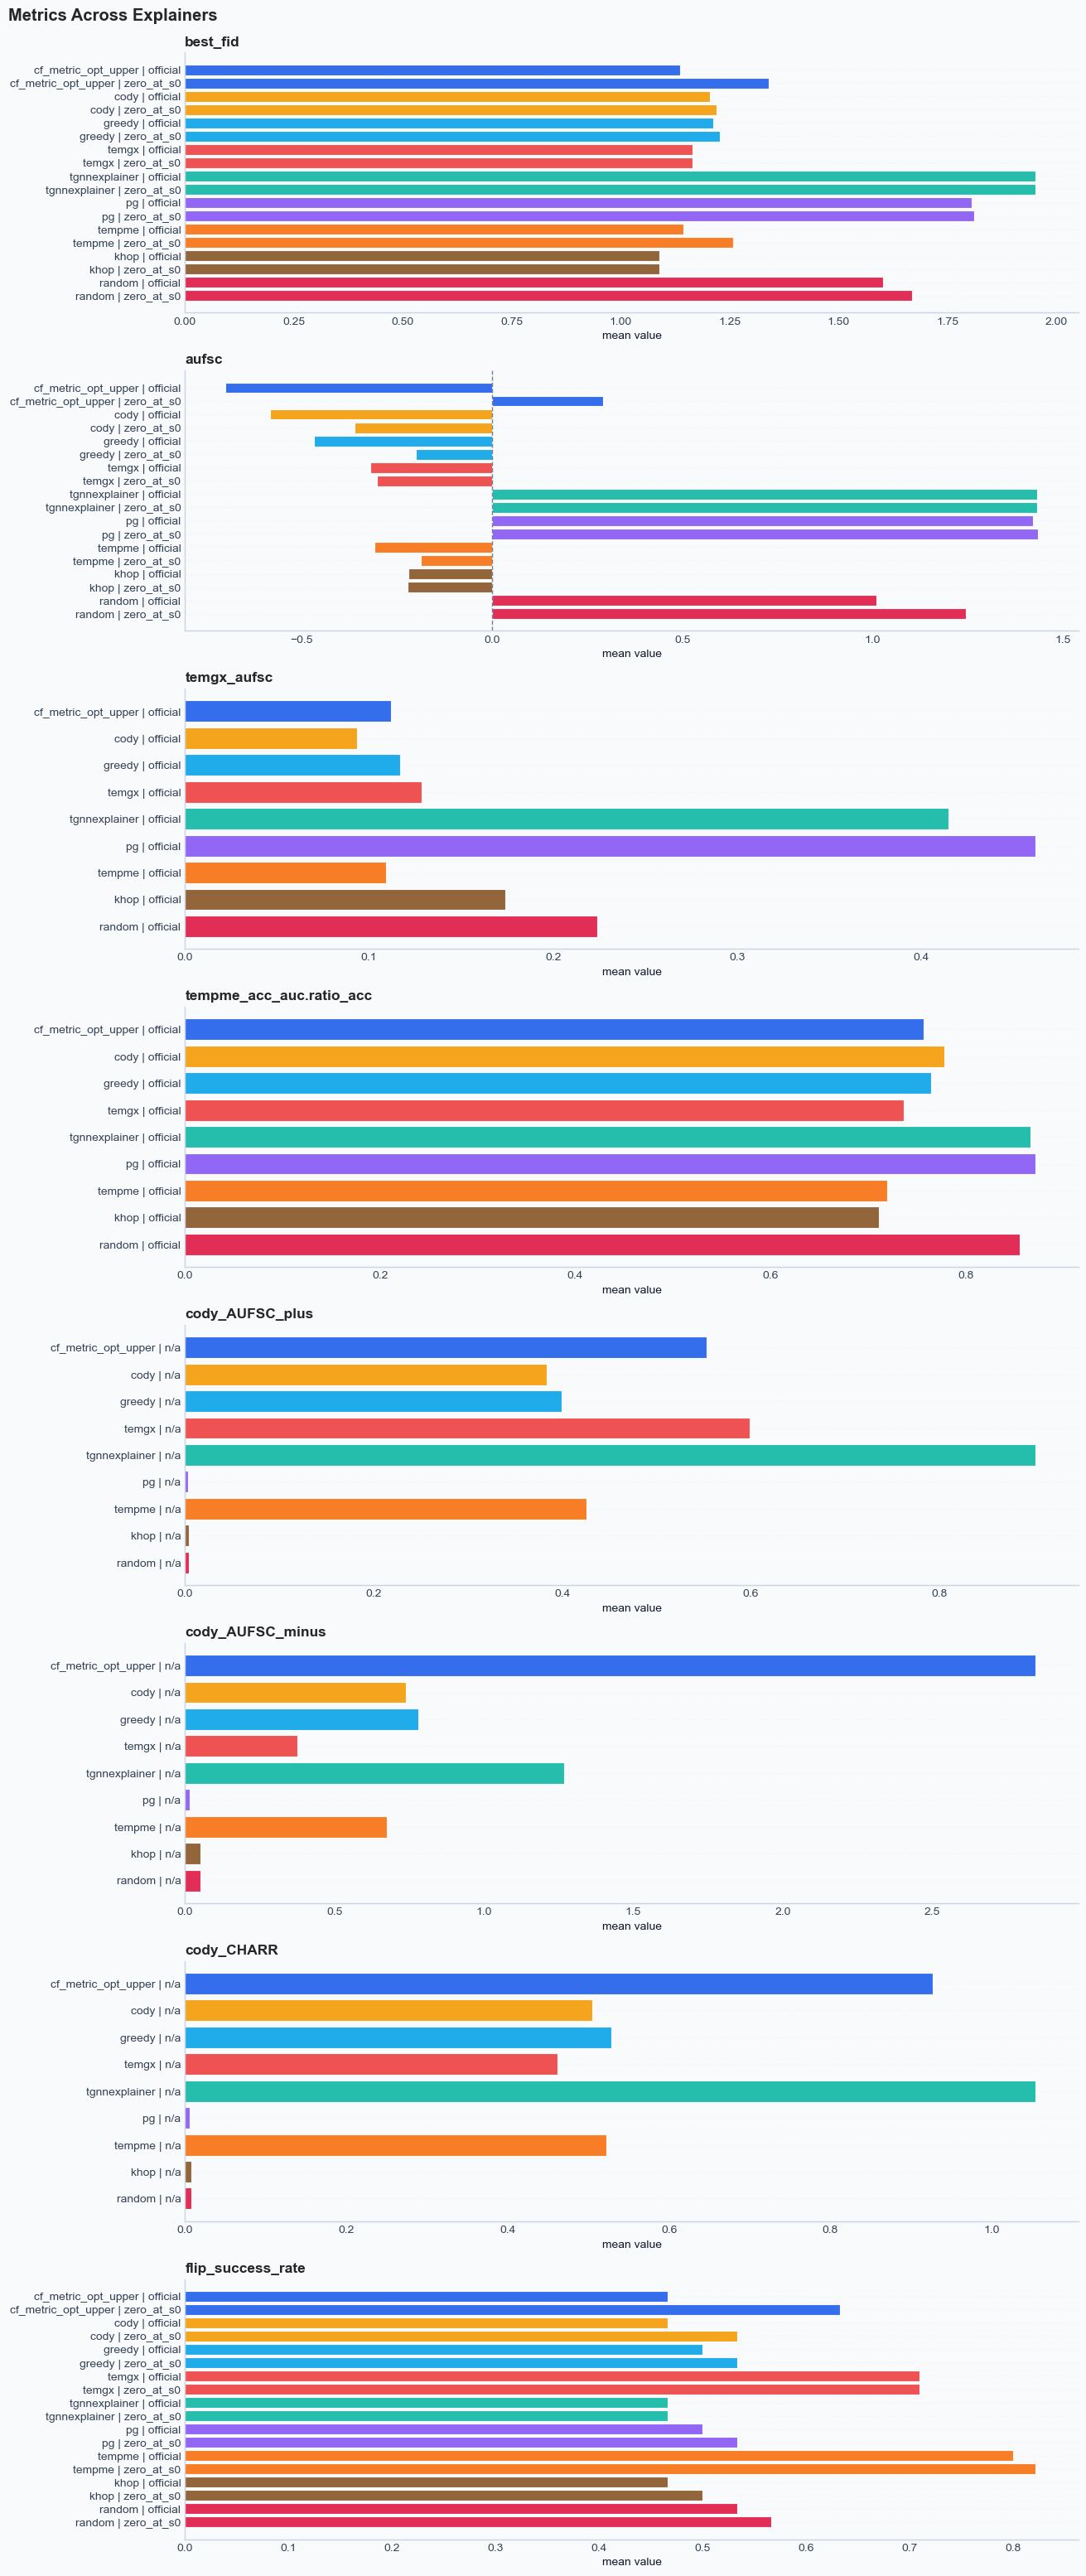

In [7]:
# Bar charts for selected metrics (modern style + PDF export)
import json
import re

plot_metrics = [m for m in METRICS_TO_PLOT if m in set(metric_table["metric"].astype(str).tolist())]
if not plot_metrics:
    raise RuntimeError(f"None of METRICS_TO_PLOT found. Available: {sorted(metric_table['metric'].astype(str).unique().tolist())}")

paper_goals_path = None
for _candidate in [
    REPO_ROOT / "papers" / "pure_metrics_goals.json",
    REPO_ROOT / "paper" / "pure_metrics_goals.json",
    BENCHMARK_ROOT / "papers" / "pure_metrics_goals.json",
    BENCHMARK_ROOT / "paper" / "pure_metrics_goals.json",
]:
    if _candidate.exists():
        paper_goals_path = _candidate
        break

paper_goal_rows = json.loads(paper_goals_path.read_text(encoding="utf-8")) if paper_goals_path is not None else []

goal_metric_alias = {
    "best_fid.value": "best_fid",
    "tgnn_aufsc.value": "aufsc",
    "temgx_aufsc.value": "temgx_aufsc",
}

def _goal_metric_name(metric_name: object) -> str:
    m = str(metric_name)
    return goal_metric_alias.get(m, m)

def _normalize_dataset_token(token: object) -> str:
    t = str(token).strip().lower()
    t = re.sub(r"[^a-z0-9]+", "", t)
    alias = {
        "wiki": "wikipedia",
        "wikipedia": "wikipedia",
        "reddit": "reddit",
        "uci": "uci",
        "uslegis": "uslegis",
        "canparl": "canparl",
        "canada parliament": "canparl",
        "enron": "enron",
    }
    return alias.get(t, t)


def _normalize_model_token(token: object) -> str:
    t = str(token).strip().lower()
    t = re.split(r"[^a-z0-9_]+", t)[0]
    alias = {
        "tgn": "tgn",
        "tgat": "tgat",
        "graphmixer": "graphmixer",
    }
    return alias.get(t, t)


def _source_matches_current(source: object, *, dataset_name: object, model_name: object) -> bool:
    m = re.search(r"\(([^/]+)/([^)]+)\)", str(source))
    if not m:
        return True

    src_dataset = _normalize_dataset_token(m.group(1))
    src_model = _normalize_model_token(m.group(2))

    want_dataset = _normalize_dataset_token(dataset_name) if dataset_name is not None else ""
    want_model = _normalize_model_token(model_name) if model_name is not None else ""

    if want_dataset and src_dataset and src_dataset != want_dataset:
        return False
    if want_model and src_model and src_model != want_model:
        return False
    return True

paper_goal_df = pd.DataFrame(paper_goal_rows)
if paper_goal_df.empty:
    paper_goal_df = pd.DataFrame(columns=["metric_plot", "explainer", "goal", "source"])
else:
    paper_goal_df = paper_goal_df.rename(columns={"goal": "goal"}).copy()
    paper_goal_df["metric_plot"] = paper_goal_df["metric"].map(_goal_metric_name)
    paper_goal_df = paper_goal_df[paper_goal_df["metric_plot"].astype(str).isin(plot_metrics)].copy()
    paper_goal_df = paper_goal_df[
        paper_goal_df["source"].map(
            lambda s: _source_matches_current(s, dataset_name=DATASET, model_name=MODEL)
        )
    ].copy()
    paper_goal_df = paper_goal_df[
        ~paper_goal_df["source"].astype(str).str.lower().str.startswith("internal baseline")
    ].copy()
    paper_goal_df["explainer"] = paper_goal_df["explainer"].astype(str)
    paper_goal_df["source"] = paper_goal_df["source"].astype(str)
    paper_goal_df["goal"] = pd.to_numeric(paper_goal_df["goal"], errors="coerce")
    # TempME table reports ratio_acc as fractions (e.g., 0.919) while this notebook
    # now plots tempme_acc_auc.ratio_acc in percent scale (e.g., 91.9).
    tempme_ratio_goal_mask = (
        paper_goal_df["metric_plot"].astype(str).eq("tempme_acc_auc.ratio_acc")
        & (paper_goal_df["goal"] >= 0.0)
        & (paper_goal_df["goal"] <= 1.5)
    )
    paper_goal_df.loc[tempme_ratio_goal_mask, "goal"] = (
        paper_goal_df.loc[tempme_ratio_goal_mask, "goal"] * 100.0
    )
    paper_goal_df = paper_goal_df.dropna(subset=["goal"]).reset_index(drop=True)

print(f"Paper goal rows loaded: {len(paper_goal_rows)} | used after filtering: {len(paper_goal_df)}")

if not paper_goal_df.empty:
    display(
        paper_goal_df[["source", "metric_plot", "explainer", "goal"]]
        .sort_values(["metric_plot", "source", "explainer"])
        .reset_index(drop=True)
    )

plot_df = (
    metric_table[metric_table["metric"].isin(plot_metrics)]
    .groupby(["metric", "explainer", "variant"], as_index=False)["value"]
    .mean()
    .sort_values(["metric", "explainer", "variant"])
)

explainer_order = _ordered_explainers(plot_df["explainer"].astype(str).unique().tolist())
variant_order = sorted(plot_df["variant"].astype(str).unique().tolist())
variant_order = [v for v in ["official", "zero_at_s0"] if v in variant_order] + [v for v in variant_order if v not in {"official", "zero_at_s0"}]
explainer_rank = {name: idx for idx, name in enumerate(explainer_order)}
variant_rank = {name: idx for idx, name in enumerate(variant_order)}
explainer_colors = _color_map(explainer_order)

n_metrics = len(plot_metrics)
fig, axes = plt.subplots(n_metrics, 1, figsize=(13.2, 3.9 * n_metrics), squeeze=False)

internal_goal_present = False
paper_goal_present = False

for row_idx, metric in enumerate(plot_metrics):
    ax = axes[row_idx, 0]
    mdf = plot_df[plot_df["metric"] == metric].copy()
    mdf["explainer"] = mdf["explainer"].astype(str)
    mdf["variant"] = mdf["variant"].astype(str)
    mdf["explainer_rank"] = mdf["explainer"].map(lambda x: explainer_rank.get(x, len(explainer_rank))).astype(int)
    mdf["variant_rank"] = mdf["variant"].map(lambda x: variant_rank.get(x, len(variant_rank))).astype(int)
    mdf = mdf.sort_values(["explainer_rank", "variant_rank", "explainer", "variant"]).reset_index(drop=True)
    mdf["label"] = mdf["explainer"] + " | " + mdf["variant"]

    colors = [explainer_colors.get(x, "#2563eb") for x in mdf["explainer"].tolist()]
    ax.barh(mdf["label"], mdf["value"], color=colors, edgecolor="#ffffff", linewidth=0.8, alpha=0.94)

    goal_rows = paper_goal_df[paper_goal_df["metric_plot"] == metric].copy()
    if not goal_rows.empty:
        for _, goal_row in goal_rows.iterrows():
            exp = str(goal_row["explainer"])
            source = str(goal_row["source"])
            x_goal = float(goal_row["goal"])

            gdf = mdf[mdf["explainer"] == exp].copy()
            if gdf.empty:
                continue
            if (gdf["variant"] == "official").any():
                gdf = gdf[gdf["variant"] == "official"].copy()

            is_internal = source.lower().startswith("internal baseline")
            marker = "o" if is_internal else "D"
            face = "none" if is_internal else "#fef08a"

            if is_internal:
                internal_goal_present = True
            else:
                paper_goal_present = True

            for _, grow in gdf.iterrows():
                ax.scatter(
                    [x_goal],
                    [grow["label"]],
                    marker=marker,
                    s=86,
                    facecolors=face,
                    edgecolors="#111827",
                    linewidths=1.4,
                    zorder=5,
                )

    if (mdf["value"] < 0).any() and (mdf["value"] > 0).any():
        ax.axvline(0.0, color="#64748b", linestyle="--", linewidth=1.0, alpha=0.9)

    ax.set_title(metric, loc="left", fontsize=12.5)
    ax.set_xlabel("mean value")
    ax.set_ylabel("")
    ax.grid(axis="x")
    ax.grid(axis="y", alpha=0.10)
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)

legend_handles = []
if paper_goal_present:
    legend_handles.append(
        plt.Line2D([0], [0], marker="D", color="none", markerfacecolor="#fde68a", markeredgecolor="#111827", markersize=7, label="paper reported value")
    )
if internal_goal_present:
    legend_handles.append(
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor="#111827", markersize=7, label="internal baseline target")
    )
if legend_handles:
    axes[0, 0].legend(handles=legend_handles, loc="lower right", fontsize=9)

fig.suptitle("Metrics Across Explainers", x=0.01, y=0.995, ha="left", fontsize=14.5, fontweight="semibold")
plt.tight_layout()
_save_pdf(fig, "metrics_bar_panel")
plt.show()




Saved plot pdf: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/figures_pdf/single_value_drop_radar_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.pdf


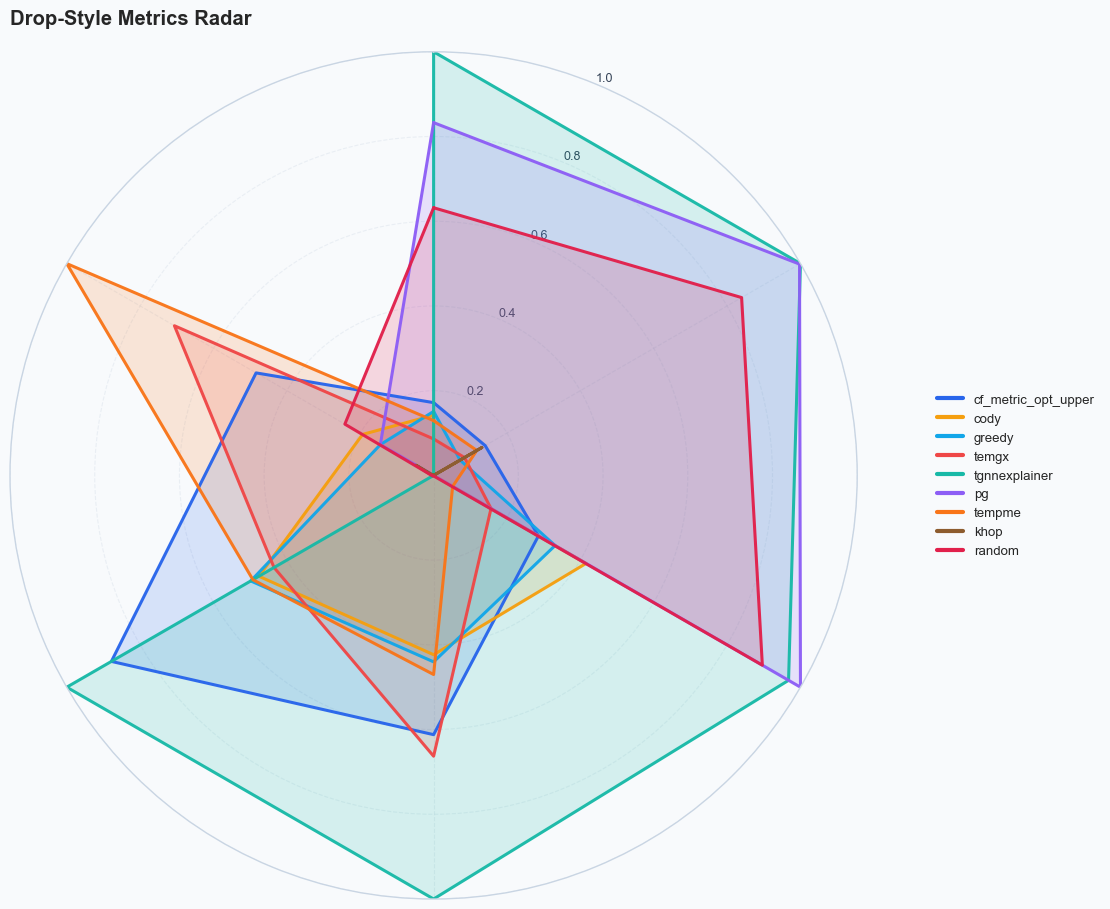

Saved plot pdf: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/figures_pdf/single_value_keep_radar_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.pdf


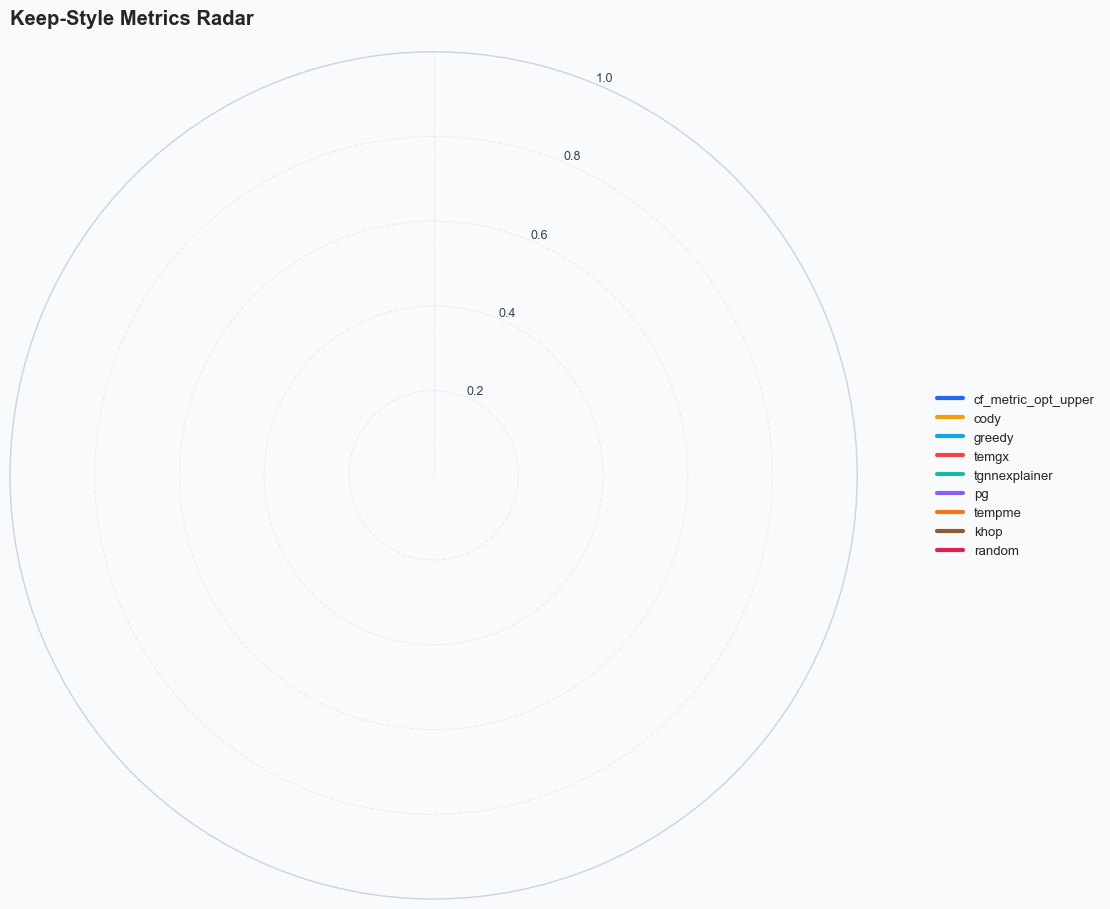

Saved plot pdf: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/figures_pdf/single_value_all_metrics_radar_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.pdf


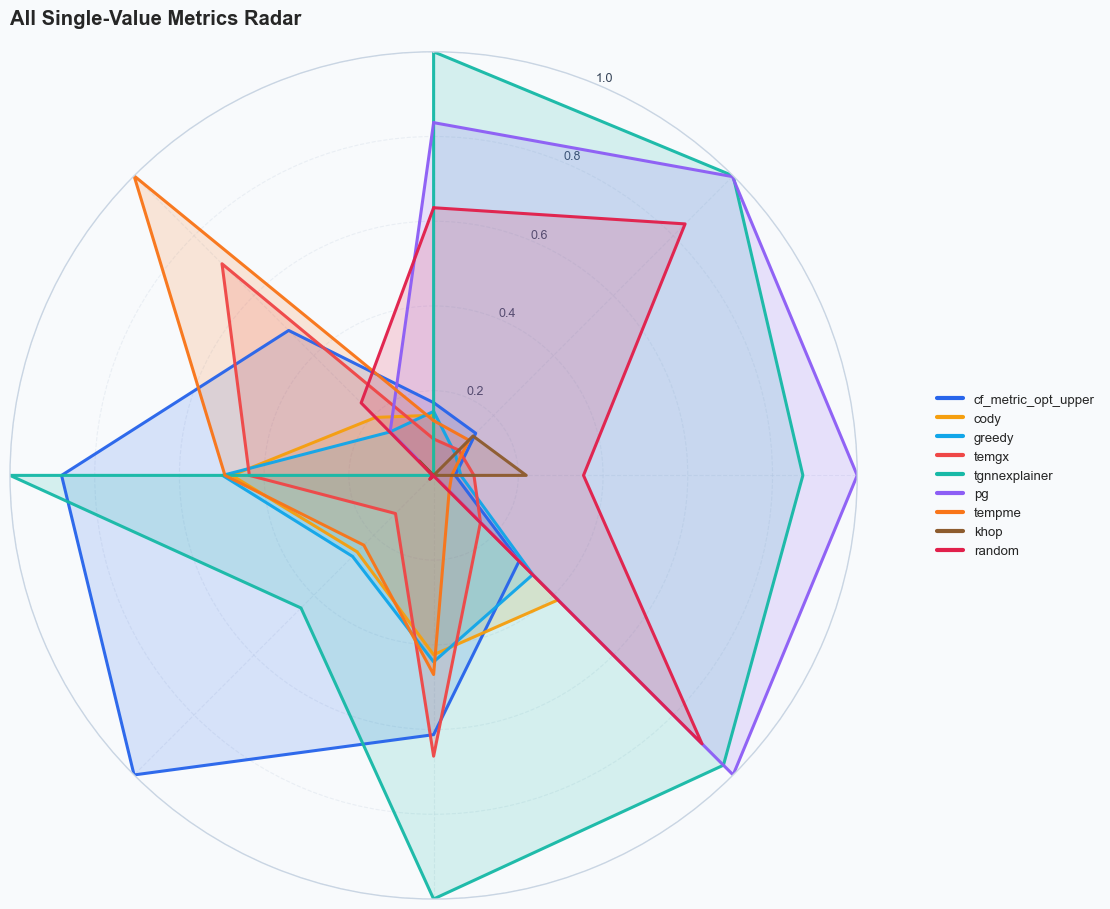

Saved plot pdf: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/figures_pdf/single_value_all_metrics_radar_by_explainer_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.pdf


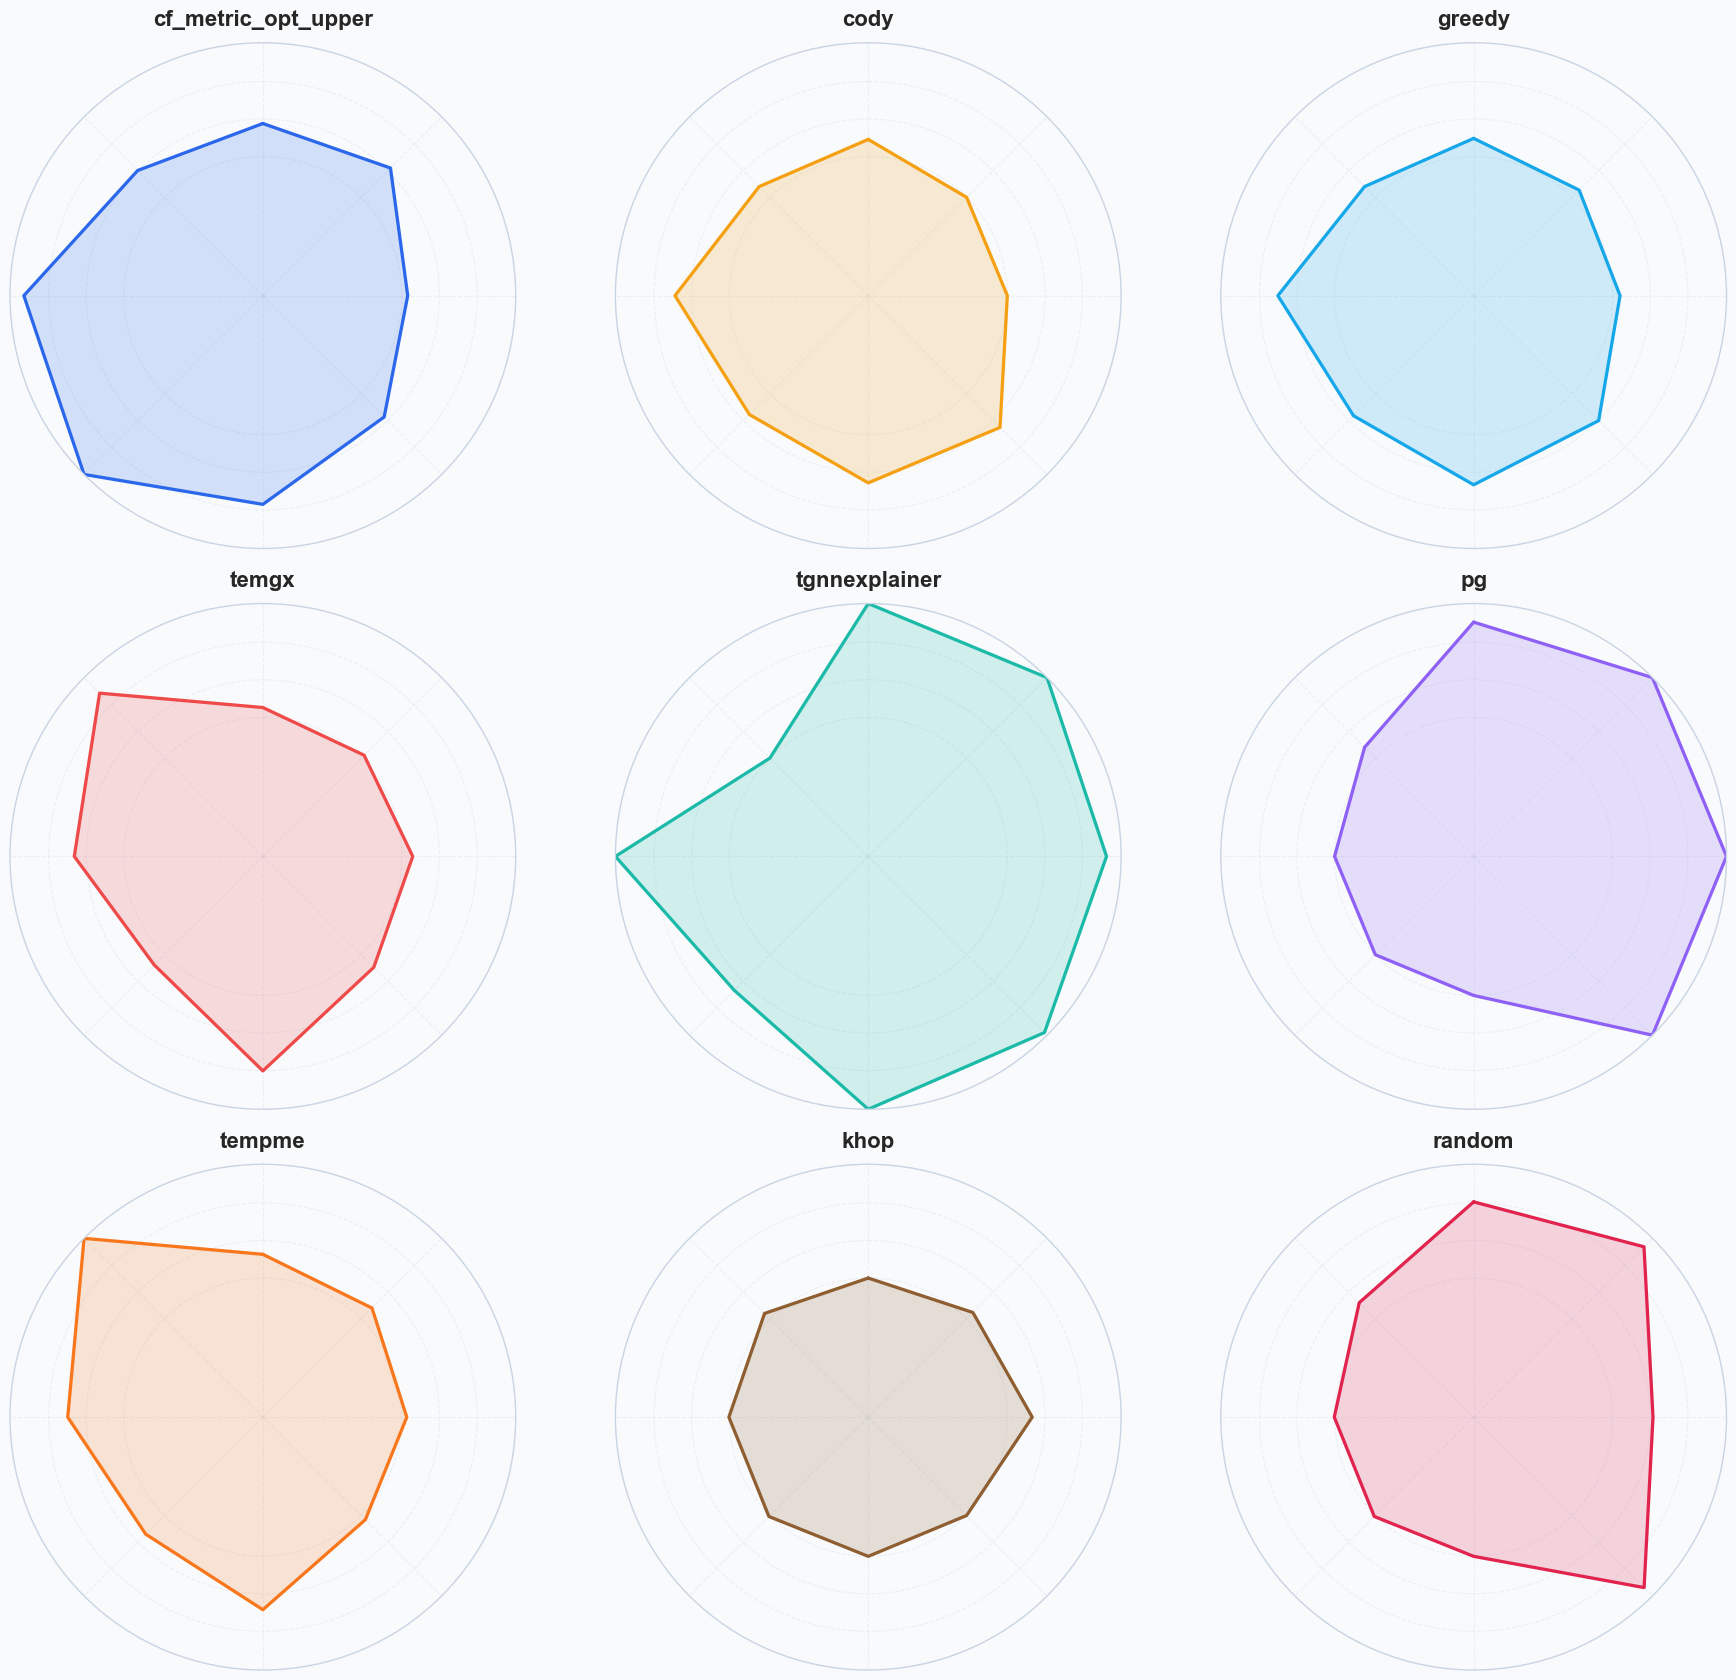

Saved plot pdf: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/figures_pdf/single_value_all_metrics_radar_by_explainer_mean_match_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.pdf


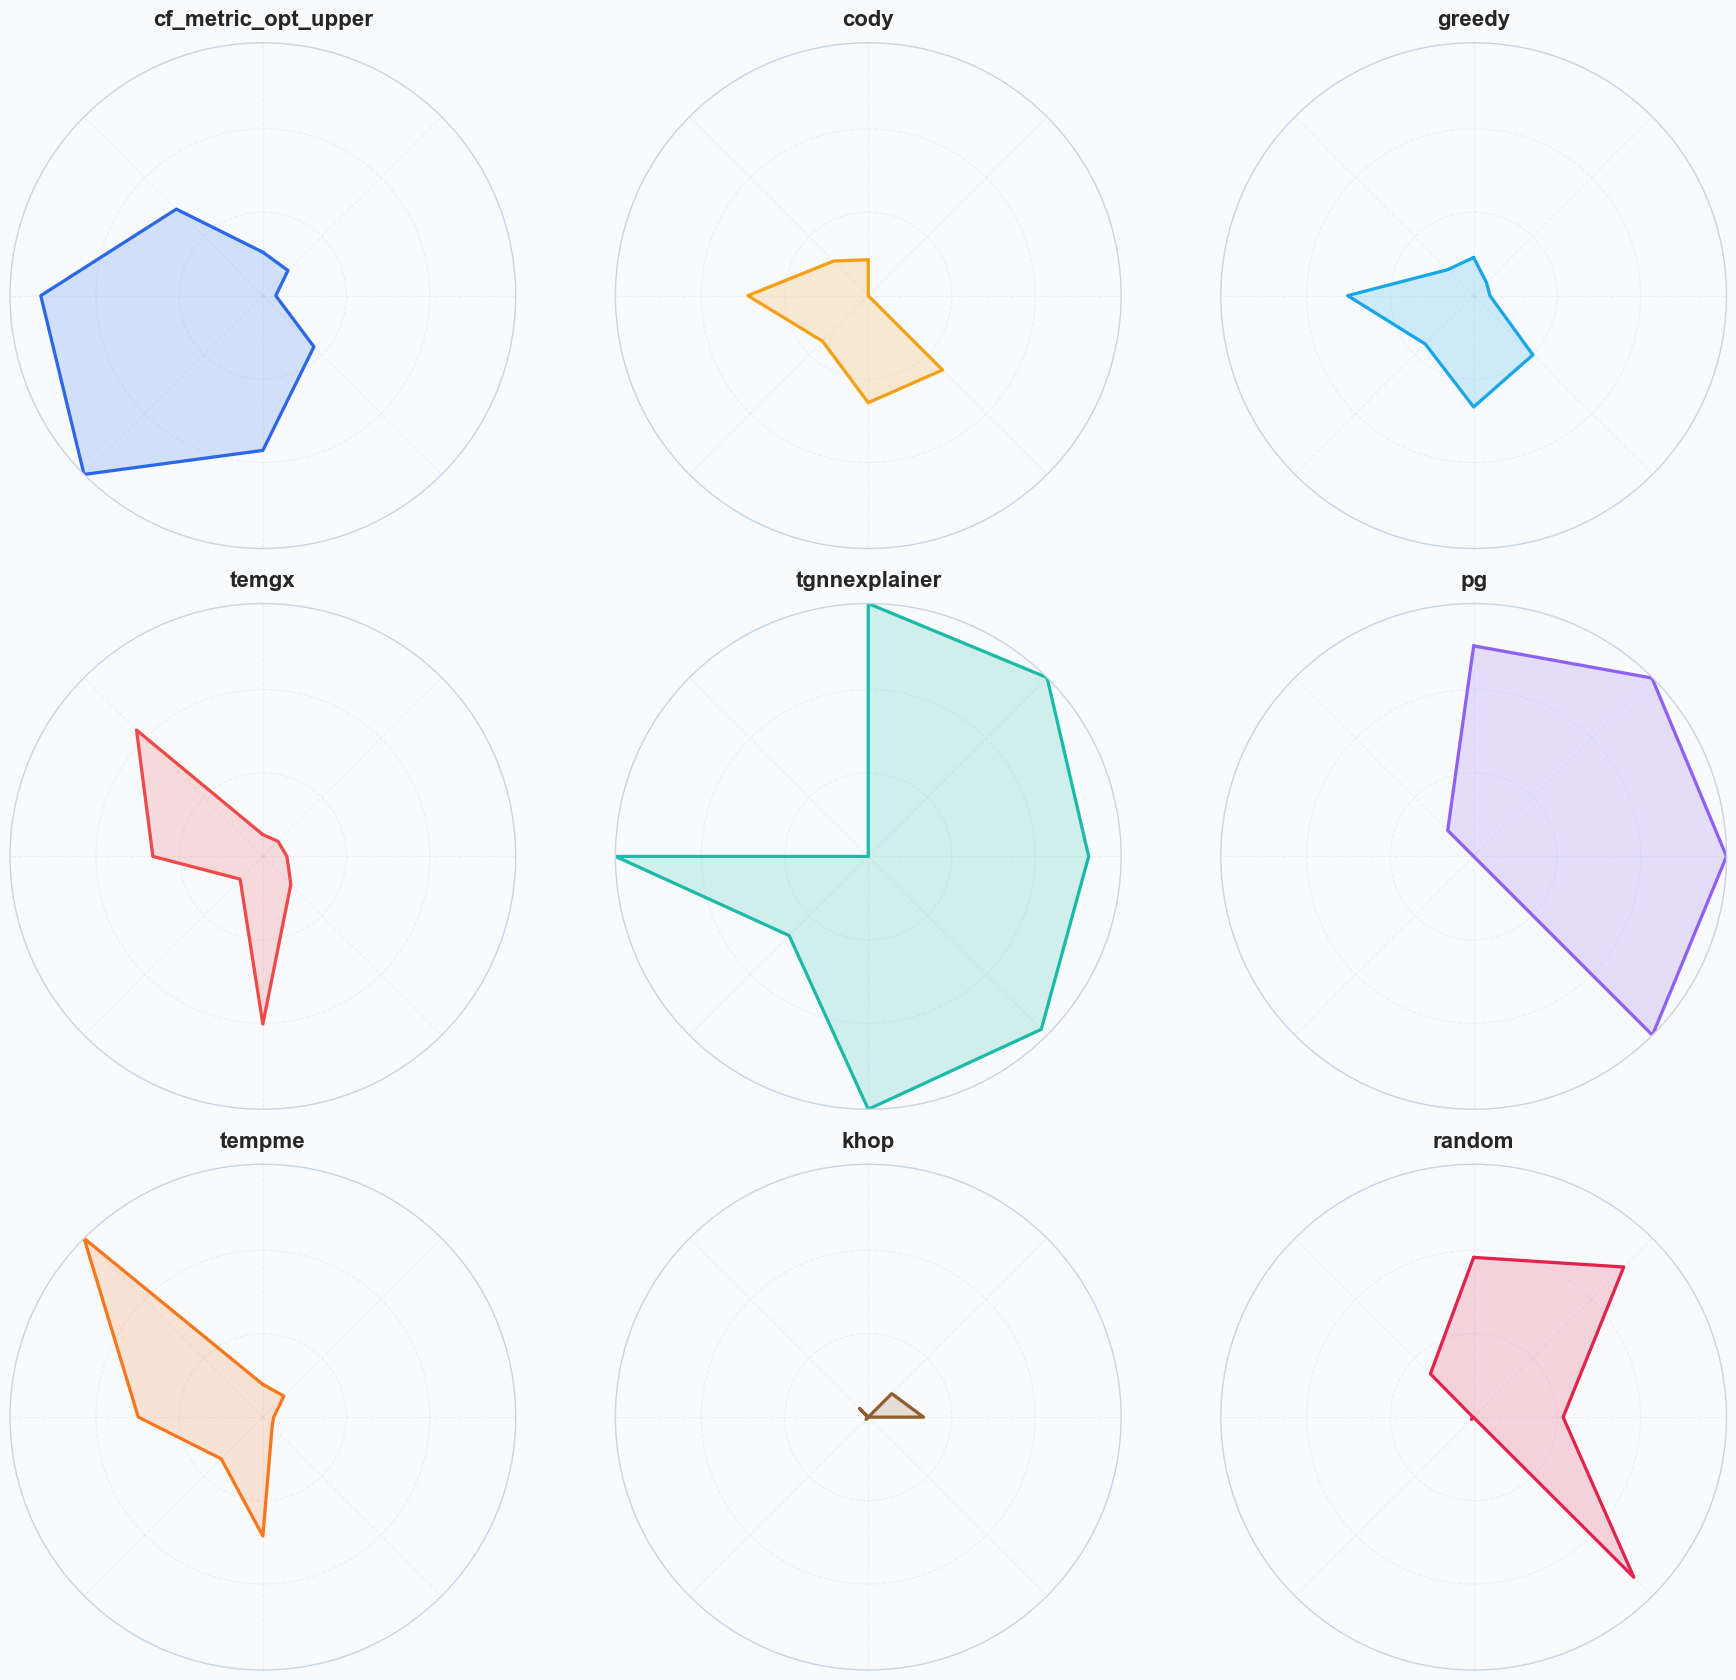

Saved plot pdf: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/figures_pdf/single_value_all_metrics_radar_by_explainer_mean_match_metric_source_background_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.pdf


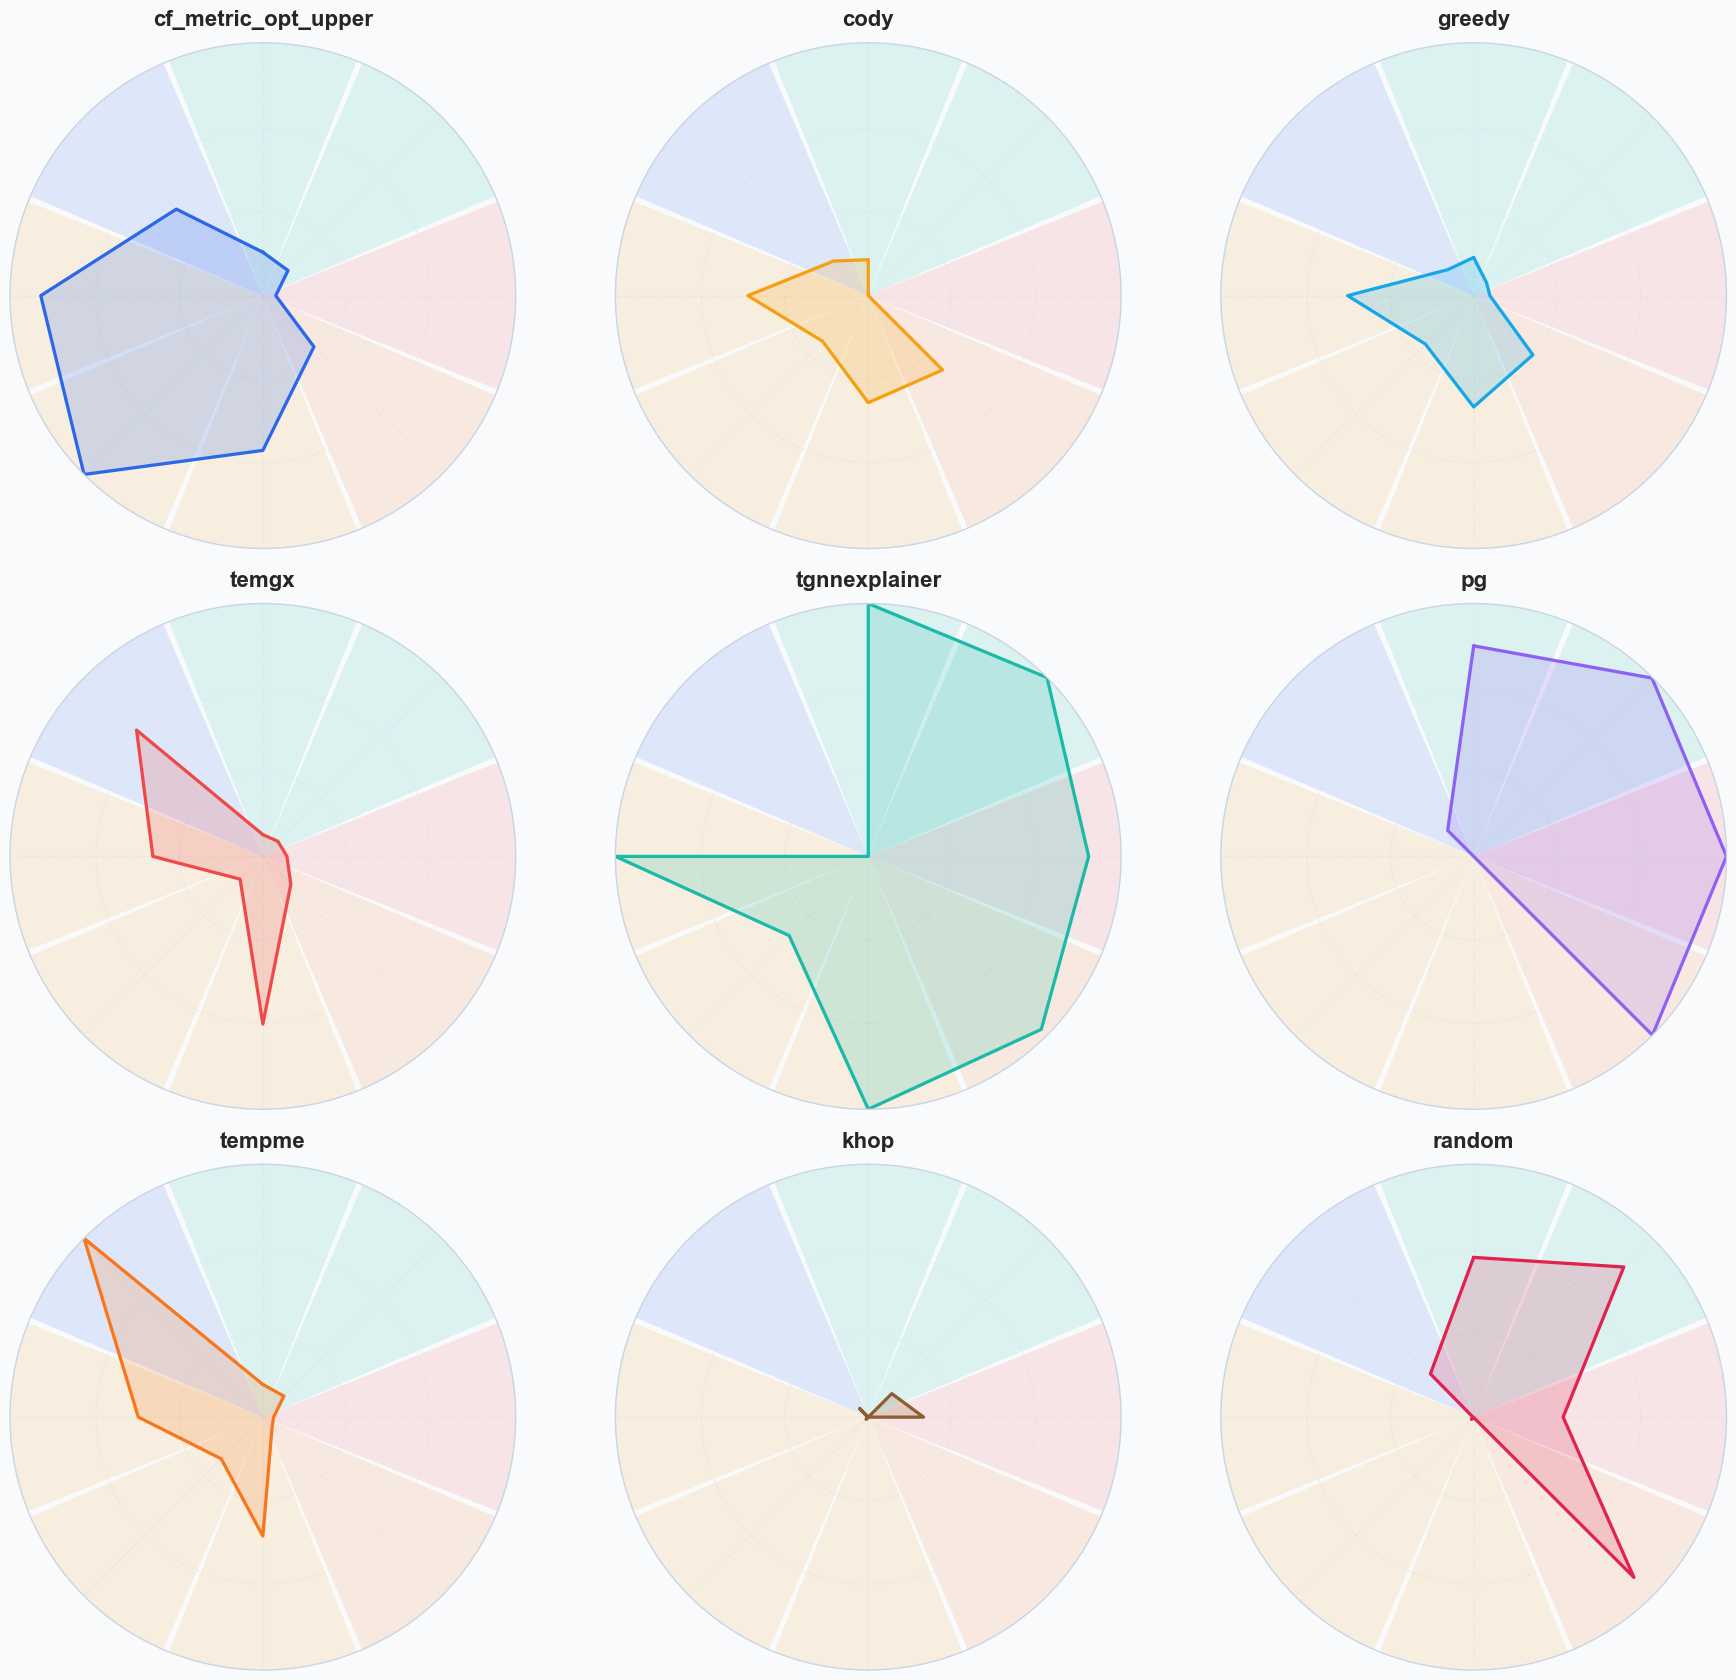

In [8]:
# Single-value metric radar charts (drop-style vs keep-style), modern view + PDF export
metric_label_map = {
    "cody_AUFSC_plus": "CoDy AUFSC +",
    "cody_AUFSC_minus": "CoDy AUFSC -",
    "cody_CHARR": "CoDy ChARR",
    "best_fid": "Best Fidelity",
    "aufsc": "AUFSC",
    "temgx_aufsc": "TemGX AUFSC",
    "best_fid_raw": "Best Fidelity (raw)",
    "best_fid_raw_sparsity": "Best Fidelity Sparsity",
    "tempme_acc_auc.ratio_acc": "TempME Acc-AUC",
    "flip_success_rate": "Flip Success Rate",
    "first_flip_sparsity": "First Flip Sparsity",
}


def _metric_label(metric: str) -> str:
    return metric_label_map.get(str(metric), str(metric))


lower_better_metrics = {"first_flip_sparsity"}

RADAR_METRICS_EXCLUDE = {
    "best_minus_aufsc",

    "best_fid_raw",
    "best_fid_raw_sparsity",
    "best_fid_raw_lt1",
    "best_fid_raw_lt1_sparsity",
    "best_fid_sparsity",
    # Tolerate typo spellings from notes/requests.
    "best_fid_raw_it",
    "best_fid_raw_it1_sparsity",
    "first_flip_sparsity",
}

RADAR_FLIP_METRIC = "flip_success_rate"
RADAR_FLIP_USE_ZERO_FOR = {"cody", "cf_metric_opt_upper"}
RADAR_FLIP_VARIANT = "zero_at_s0"

RADAR_METRIC_PRIORITY = [
    # TGNN family
    "best_fid",
    "aufsc",
    # TemGX family
    "temgx_aufsc",

    # TempME family
    "tempme_acc_auc.ratio_acc",

    # CoDy family
    "cody_AUFSC_plus",
    "cody_AUFSC_minus",
    "cody_CHARR",

    # Counterfactual family
    "flip_success_rate",
]


def _radar_metric_allowed(metric: object) -> bool:
    name = str(metric)
    if name in RADAR_METRICS_EXCLUDE:
        return False
    if name == "elapsed_sec":
        return False
    if name.startswith("tempme_") and name != "tempme_acc_auc.ratio_acc":
        return False
    return True


def _order_radar_metrics(metrics: list[str]) -> list[str]:
    unique_metrics = []
    seen = set()
    for m in metrics:
        ms = str(m)
        if ms in seen:
            continue
        seen.add(ms)
        unique_metrics.append(ms)

    priority = {name: idx for idx, name in enumerate(RADAR_METRIC_PRIORITY)}
    default_rank = len(RADAR_METRIC_PRIORITY)
    return sorted(unique_metrics, key=lambda name: (priority.get(name, default_rank), _metric_label(name)))



def _radar_rows_for_metrics(available: list[str]) -> pd.DataFrame:
    rows = metric_table[metric_table["metric"].isin(available)].copy()
    if rows.empty:
        return rows

    if not {"metric", "explainer", "variant"}.issubset(set(rows.columns)):
        return rows

    m = rows["metric"].astype(str)
    e = rows["explainer"].astype(str)
    v = rows["variant"].astype(str)

    for explainer_name in sorted(RADAR_FLIP_USE_ZERO_FOR):
        exp_mask = (m == RADAR_FLIP_METRIC) & (e == str(explainer_name))
        if not exp_mask.any():
            continue

        zero_mask = exp_mask & (v == RADAR_FLIP_VARIANT)
        if zero_mask.any():
            rows = rows[(~exp_mask) | zero_mask].copy()
            m = rows["metric"].astype(str)
            e = rows["explainer"].astype(str)
            v = rows["variant"].astype(str)

    return rows


def _polygon_area_xy(x: np.ndarray, y: np.ndarray) -> float:
    if x.size < 3 or y.size < 3:
        return 0.0
    return float(0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))


METRIC_SOURCE_EXPLAINER = {
    "best_fid": "tgnnexplainer",
    "aufsc": "tgnnexplainer",
    "best_fid_raw": "tgnnexplainer",
    "best_fid_raw_sparsity": "tgnnexplainer",
    "temgx_aufsc": "temgx",
    "flip_success_rate": "cf_metric_opt_upper",
    "first_flip_sparsity": "cf_metric_opt_upper",
    "cody_AUFSC_plus": "cody",
    "cody_AUFSC_minus": "cody",
    "cody_CHARR": "cody",
    "tempme_acc_auc.ratio_acc": "tempme",
}


def _metric_source_explainer(metric: str) -> str | None:
    name = str(metric)
    if name in METRIC_SOURCE_EXPLAINER:
        return str(METRIC_SOURCE_EXPLAINER[name])
    if name.startswith("cody_"):
        return "cody"
    if name.startswith("tempme_"):
        return "tempme"
    if name.startswith("temgx_"):
        return "temgx"
    if name.startswith("cf_metric_opt") or name.startswith("flip_"):
        return "cf_metric_opt_upper"
    if name.startswith("tgnn_"):
        return "tgnnexplainer"
    return None


def _metric_source_color_map(
    explainers: list[str],
    metrics: list[str],
    base_color_map: dict[str, str],
) -> dict[str, str]:
    labels = [str(x) for x in explainers]
    for metric_name in metrics:
        source = _metric_source_explainer(metric_name)
        if source is not None:
            labels.append(str(source))
    cmap = _color_map(labels)
    for name, color in base_color_map.items():
        cmap[str(name)] = str(color)
    return cmap


def _paint_metric_source_background(
    ax: plt.Axes,
    *,
    angles: np.ndarray,
    metrics: list[str],
    source_color_map: dict[str, str],
    alpha: float = 0.12,
) -> None:
    if len(metrics) == 0:
        return
    width = (2.0 * np.pi / float(len(metrics))) * 0.97
    alpha_val = float(np.clip(alpha, 0.0, 1.0))
    for theta, metric_name in zip(angles, metrics):
        source = _metric_source_explainer(metric_name)
        if source is None:
            color = "#e2e8f0"
        else:
            color = source_color_map.get(str(source), "#cbd5e1")
        ax.bar(
            float(theta),
            1.0,
            width=width,
            bottom=0.0,
            color=color,
            alpha=alpha_val,
            edgecolor="none",
            align="center",
            zorder=0,
        )


def _plot_single_value_radar(metric_group: list[str], *, title: str, file_stub: str) -> None:
    available = [
        m
        for m in metric_group
        if (m in set(metric_table["metric"].astype(str).tolist()) and _radar_metric_allowed(m))
    ]
    available = _order_radar_metrics(available)
    if not available:
        print(f"Skipping {title!r}: no metrics available after filtering.")
        return

    radar_rows = _radar_rows_for_metrics(available)
    score_df = (
        radar_rows
        .groupby(["explainer", "metric"], as_index=False)["value"]
        .mean()
    )
    if score_df.empty:
        print(f"Skipping {title!r}: no rows after aggregation.")
        return

    raw = score_df.pivot_table(index="explainer", columns="metric", values="value", aggfunc="mean")
    raw = raw[[m for m in available if m in raw.columns]].copy()
    if raw.empty:
        print(f"Skipping {title!r}: pivot empty.")
        return

    norm = raw.copy()
    for col in norm.columns:
        vals = pd.to_numeric(norm[col], errors="coerce").to_numpy(dtype=float)
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            norm[col] = np.nan
            continue
        vmin = float(np.min(finite))
        vmax = float(np.max(finite))
        if abs(vmax - vmin) < 1e-12:
            norm[col] = 0.5
        else:
            if str(col) in lower_better_metrics:
                norm[col] = (vmax - vals) / (vmax - vmin)
            else:
                norm[col] = (vals - vmin) / (vmax - vmin)

    norm = norm.fillna(0.0)
    explainer_order = [name for name in _ordered_explainers(norm.index.tolist()) if name in norm.index]
    raw = raw.loc[explainer_order]
    norm = norm.loc[explainer_order]

    metrics = norm.columns.astype(str).tolist()
    n_metrics = len(metrics)
    if n_metrics == 0:
        print(f"Skipping {title!r}: no metric columns after normalization.")
        return

    angles = np.linspace(0.0, 2.0 * np.pi, n_metrics, endpoint=False)
    angles_closed = np.concatenate([angles, [angles[0]]])

    color_map = _color_map([str(x) for x in norm.index.tolist()])

    fig, ax = plt.subplots(1, 1, figsize=(10.8, 9.2), subplot_kw={"projection": "polar"})
    ax.set_theta_offset(np.pi / 2.0)
    ax.set_theta_direction(-1)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=9)
    ax.set_xticks(angles)
    ax.set_xticklabels([""] * len(metrics), fontsize=10)
    ax.grid(alpha=0.45, linestyle="--")

    legend_rows = []
    for explainer in norm.index.tolist():
        vals = norm.loc[explainer].to_numpy(dtype=float)
        vals_closed = np.concatenate([vals, [vals[0]]])
        color = color_map.get(str(explainer), "#2563eb")

        ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, alpha=0.96)
        ax.fill(angles_closed, vals_closed, color=color, alpha=0.16)

        legend_rows.append((str(explainer), color))

    handles = []
    labels = []
    for name, color in legend_rows:
        h = plt.Line2D([0], [0], color=color, lw=3)
        handles.append(h)
        labels.append(name)

    ax.set_title(title, loc="left", fontsize=14.5, fontweight="semibold", pad=20)
    ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.08, 0.5), frameon=False, fontsize=9.5)

    plt.tight_layout()
    _save_pdf(fig, file_stub)
    plt.show()


_plot_single_value_radar(
    DROP_STYLE_METRICS,
    title="Drop-Style Metrics Radar",
    file_stub="single_value_drop_radar",
)

_plot_single_value_radar(
    KEEP_STYLE_METRICS,
    title="Keep-Style Metrics Radar",
    file_stub="single_value_keep_radar",
)

all_metric_candidates = []
for metric_source in [
    METRICS_TO_PLOT,
    DROP_STYLE_METRICS,
    KEEP_STYLE_METRICS,
    sorted(metric_table["metric"].astype(str).unique().tolist()),
]:
    for m in metric_source:
        ms = str(m)
        if _radar_metric_allowed(ms) and (ms not in all_metric_candidates):
            all_metric_candidates.append(ms)

_plot_single_value_radar(
    all_metric_candidates,
    title="All Single-Value Metrics Radar",
    file_stub="single_value_all_metrics_radar",
)

# New: radial small-multiples for all explainers (maximize area by using per-metric max aggregation)
def _radar_matrix(metric_group: list[str], *, agg_mode: str = "max", fill_missing: float = 0.5) -> tuple[pd.DataFrame, pd.DataFrame]:
    available = [
        m
        for m in metric_group
        if (m in set(metric_table["metric"].astype(str).tolist()) and _radar_metric_allowed(m))
    ]
    available = _order_radar_metrics(available)
    if not available:
        return pd.DataFrame(), pd.DataFrame()

    agg_mode = str(agg_mode).strip().lower()
    if agg_mode not in {"max", "mean"}:
        agg_mode = "max"

    radar_rows = _radar_rows_for_metrics(available)
    score_df = (
        radar_rows
        .groupby(["explainer", "metric"], as_index=False)["value"]
        .agg(agg_mode)
    )
    if score_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    raw = score_df.pivot_table(index="explainer", columns="metric", values="value", aggfunc="first")
    raw = raw[[m for m in available if m in raw.columns]].copy()
    if raw.empty:
        return pd.DataFrame(), pd.DataFrame()

    norm = raw.copy()
    for col in norm.columns:
        vals = pd.to_numeric(norm[col], errors="coerce").to_numpy(dtype=float)
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            norm[col] = np.nan
            continue
        vmin = float(np.min(finite))
        vmax = float(np.max(finite))
        if abs(vmax - vmin) < 1e-12:
            norm[col] = 0.5
        else:
            if str(col) in lower_better_metrics:
                norm[col] = (vmax - vals) / (vmax - vmin)
            else:
                norm[col] = (vals - vmin) / (vmax - vmin)

    # Use neutral fill for missing metrics so explainers with partial metric coverage stay comparable.
    norm = norm.fillna(float(fill_missing))
    return raw, norm


def _plot_all_explainers_radar(
    metric_group: list[str],
    *,
    title: str,
    file_stub: str,
    agg_mode: str = "max",
    radial_floor: float = 0.55,
    fill_missing: float = 0.5,
    metric_source_background: bool = False,
    metric_source_background_alpha: float = 0.12,
) -> None:
    raw, norm = _radar_matrix(metric_group, agg_mode=agg_mode, fill_missing=fill_missing)
    if raw.empty or norm.empty:
        print(f"Skipping {title!r}: no radar data after aggregation.")
        return

    explainers = [str(x) for x in _ordered_explainers(norm.index.tolist()) if str(x) in set(norm.index.astype(str).tolist())]
    if explainers:
        raw = raw.loc[explainers]
        norm = norm.loc[explainers]
    metrics = [str(x) for x in norm.columns.tolist()]
    n_exp = len(explainers)
    n_met = len(metrics)
    if n_exp == 0 or n_met == 0:
        print(f"Skipping {title!r}: missing explainers/metrics.")
        return

    angles = np.linspace(0.0, 2.0 * np.pi, n_met, endpoint=False)
    angles_closed = np.concatenate([angles, [angles[0]]])

    cols = min(3, max(1, n_exp))
    rows = int(np.ceil(n_exp / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6.2 * cols, 5.8 * rows), subplot_kw={"projection": "polar"})
    if rows == 1 and cols == 1:
        axes_list = [axes]
    else:
        axes_list = np.ravel(np.asarray(axes)).tolist()

    color_map = _color_map(explainers)
    source_color_map = _metric_source_color_map(explainers, metrics, color_map)

    for i, explainer in enumerate(explainers):
        ax = axes_list[i]
        vals = norm.loc[explainer].to_numpy(dtype=float)

        # Stretch outward to visually enlarge area while preserving metric ordering.
        rf = float(np.clip(radial_floor, 0.0, 0.9))
        vals_plot = rf + (1.0 - rf) * vals
        vals_closed = np.concatenate([vals_plot, [vals_plot[0]]])

        color = color_map.get(explainer, "#2563eb")
        ax.set_theta_offset(np.pi / 2.0)
        ax.set_theta_direction(-1)
        ax.set_ylim(0.0, 1.0)
        ax.set_xticks(angles)
        ax.set_xticklabels([""] * len(metrics), fontsize=8.7)
        ax.set_yticks([rf, rf + (1-rf)*0.33, rf + (1-rf)*0.66, 1.0])
        ax.set_yticklabels([], fontsize=8)

        if metric_source_background:
            _paint_metric_source_background(
                ax,
                angles=angles,
                metrics=metrics,
                source_color_map=source_color_map,
                alpha=metric_source_background_alpha,
            )

        ax.grid(alpha=0.40, linestyle="--")

        ax.plot(angles_closed, vals_closed, color=color, linewidth=2.35, alpha=0.98)
        ax.fill(angles_closed, vals_closed, color=color, alpha=0.18)

        ax.set_title(str(explainer), fontsize=16, loc="center", pad=12)

    for j in range(n_exp, len(axes_list)):
        axes_list[j].set_axis_off()

    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.6, rect=[0.0, 0.0, 1.0, 0.97])
    _save_pdf(fig, file_stub)
    plt.show()


_plot_all_explainers_radar(
    all_metric_candidates,
    title="All Metrics Radar by Explainer (max profile)",
    file_stub="single_value_all_metrics_radar_by_explainer",
    agg_mode="max",
    radial_floor=0.55,
)

_plot_all_explainers_radar(
    all_metric_candidates,
    title="All Metrics Radar by Explainer (mean profile, same as combined radar)",
    file_stub="single_value_all_metrics_radar_by_explainer_mean_match",
    agg_mode="mean",
    radial_floor=0.0,
    fill_missing=0.0,
)


_plot_all_explainers_radar(
    all_metric_candidates,
    title="All Metrics Radar by Explainer (mean profile, metric-source background)",
    file_stub="single_value_all_metrics_radar_by_explainer_mean_match_metric_source_background",
    agg_mode="mean",
    radial_floor=0.0,
    fill_missing=0.0,
    metric_source_background=True,
    metric_source_background_alpha=0.12,
)






In [9]:
# Optional: export this notebook's filtered view
summary_out = SUMMARY_ROOT / "summary_views"
summary_out.mkdir(parents=True, exist_ok=True)

tag = f"dataset-{DATASET or 'all'}_model-{MODEL or 'all'}_mode-{RUN_SELECTION}"
metric_view_path = summary_out / f"metrics_view_{tag}.csv"
curve_view_path = summary_out / f"curve_view_{tag}.csv"

metric_table.to_csv(metric_view_path, index=False)
curve_mean_f.to_csv(curve_view_path, index=False)

print("Saved metric view:", metric_view_path)
print("Saved curve view :", curve_view_path)


Saved metric view: /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/metrics_view_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.csv
Saved curve view : /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/I_explainer_benchmark/resources/results/summary_ready/summary_views/curve_view_dataset-simulate_v1_model-tgn_mode-latest_per_explainer_variant.csv
